# **Port Charles stress test case - Influence of input parameters**

We are now going to toy around with some of the inputs. We will focus on the influence of
- Adjusting the simulation region
- Boundary conditions (river injections, tide...)
- Grid resolution
> See parameters section of the manual for details https://cyprienbosserelle.github.io/BG_Flood/ParametersList-py/
---


### **1. Adjusting the region of interest**
If you 

```markdown
# Port Charles stress test 

################
# DEM
################
dem = PortCharles_DEM.nc?z

################
# Grid refinement
################
dx = 32.0;

################
# Forcing
################
# Rainfall prescribed in mm/h as
# 1. Uniform rainfall: tab delimited timeseries *.txt file [time rainfall]
# 2. Spatially varying: Mapped as multi-time *.nc (netcdf) file. 
rain = rain.txt

################
# Roughness
################
# Multiple surface roughness models exist: Here we use the dynamic Smart (2012) model
frictionmodel = 1
roughness = 0.04

################
# Boundaries
################
# Main types of boundaries depending on the flag
# 0: Wall
# 1: Zero-gradient (Neumann: Used for opening outlet
# 2: Fixed value (Dirichlet) - Requires timeseries file: Used for tides
# 3: Absorbing wave - Same as 2 but more stable numerically (allows waves to exit the domain)
left = 0;
right = 0;
top = 0;
bot = 0;

################
# Solver parameters
################

engine = 2
vmax=16.0

################
# output parameters
################

endtime = 4800.0
outputtimestep = 300.00;

outvars = h, zs, u, v, hmax, zsmax, Umax, hUmax;

outfile = Port_Charles_dx32m.nc
```
---

### **3. First BG-Flood run**

We have 2 options to execute BG-Flood
1. Terminal command: move to the project directory and run 
```
path\to\BG_Flood\BG_Flood.exe
```

2. Copy paste the content of the compiled directory `path\to\BG_Flood\` (all of it!) and double click `BG_Flood.exe`

---

### **4. Checking the results**

#### 1. In QGIS
To quickly check the output, simply drag and drop the output file into QGIS.

Try to open the results ***Port_Charles_dx32m.nc*** and read the variable ***h_P0***.

> The output variables have a suffix *_P0. We will explain its origin later

#### 2. In Python
The conda environment should already be installed at this stage. If not, refer to section 3 of the *BG_Flood_introduction.ipynb*.

We will use the packages xarray and rioxarray to open the files and plot as follow

In [20]:
#%%% IMPORT PACKAGES
import xarray as xr
import rioxarray
import numpy as np
#import folium


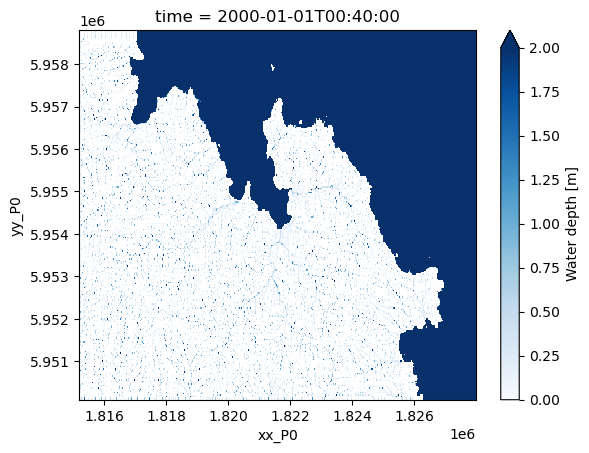

In [46]:
#%%% SIMPLE PLOT



# Replace with the path to your output file.
BGout_path = "/mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32m.nc"
#BGout_path = "\path\to\Tutorial_1\Port_Charles_dx32m.nc"

# Open the dataset with xarray.
ds = xr.open_dataset(BGout_path)

# Simple plot
timestep = 4
ds["h_P0"][timestep].plot(vmin=0, vmax=2, cmap="Blues")


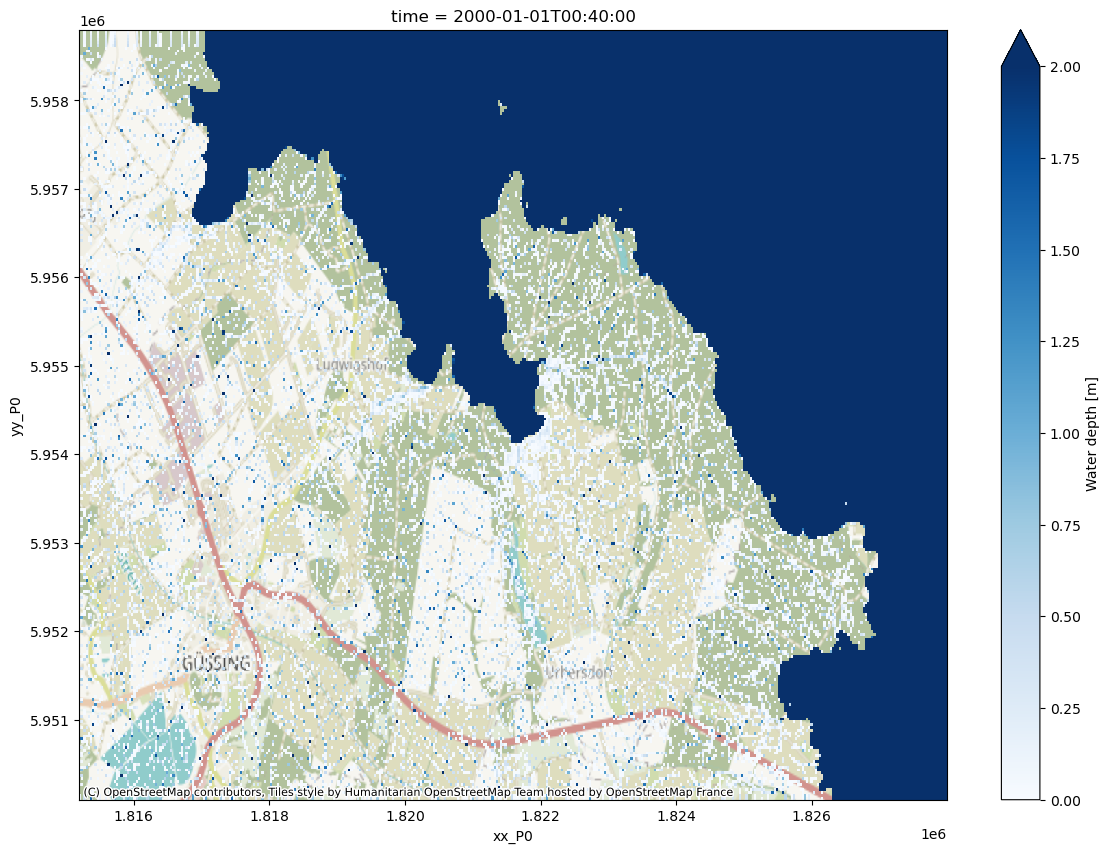

In [52]:
# Try to add OpenStreetMap as background
import contextily as ctx
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 10))

timestep = 4
ds["h_P0"][timestep].plot(ax=ax, vmin=0, vmax=2, cmap="Blues")

ctx.add_basemap(
    ax,
)

In [42]:
#%%% Simple plot

# Function to read in the output file and concatenate variables across levels.
def prep_BGout(file_path, list_variables=["h"], crs="EPSG:2193"):
    print(f" # Reading input file {file_path}...")
    with xr.open_dataset(file_path) as ds:
        for var in list_variables:
            print(f"    . Treatment of variable {var}...")
            lvl_str = f"P0"
            da_lvl = ds[f"{var}_{lvl_str}"]
            da_lvl = da_lvl.rename({
                f"yy_{lvl_str}": "y",
                f"xx_{lvl_str}": "x",
            })
            da_lvl = da_lvl.rename(var)
            da_lvl_out = da_lvl.copy()
            y = da_lvl_out.y
            x = da_lvl_out.x

            da_lvl_out = da_lvl_out.rio.write_crs(crs, inplace=True)

        dsout[var] = da_lvl_out

    dsout.rio.write_crs(crs, inplace=True)
    dsout.rio.write_coordinate_system(inplace=True)

    return dsout


# Replace with the path to your output file.
BGout_path = "/mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32mTo8m_Kurganov.nc"
#BGout_path = "\path\to\Tutorial_1\Port_Charles_dx32m.nc"
save_flag = False

# List of variables to concatenate across levels.
list_variables = ["h", "u", "v", "zs", "hmax", "zsmax", "Umax"]

# Initialise output file
dsout = xr.Dataset()

# Rename variables and dimensions to remove 

dsout = prep_BGout(BGout_path, list_variables, crs="EPSG:2193")
# Save file
if save_flag:
    outfile_path = "/mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32mTo8m_Kurganov_concat.nc"
    dsout.to_netcdf(outfile_path)


 # Reading input file /mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32mTo8m_Kurganov.nc...
    . Treatment of variable h...
    . Treatment of variable u...
    . Treatment of variable v...
    . Treatment of variable zs...
    . Treatment of variable hmax...
    . Treatment of variable zsmax...
    . Treatment of variable Umax...


In [ ]:
# Concatenation of outputs from different refinement levels.
# The output file is written in the same format as the input file, but with the variables concatenated across levels.
# The output file can be used for further analysis or visualization.

BGout_path = "/mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32mTo8m_Kurganov.nc"

# Min and max refinement levels to concatenate.
minlevel = 0
maxlevel = 2

# List of variables to concatenate across levels.
list_variables = ["h", "u", "v", "zs", "hmax", "zsmax", "Umax"]

# Initialise output file
dsout = xr.Dataset()

print(" # Reading input file...")
with xr.open_dataset(BGout_path) as ds:
    for var in list_variables:
        print(f"    . Treatment of variable {var}...")
        for lvl in range(maxlevel, minlevel-1, -1):
            lvl_str = f"P{lvl}"
            da_lvl = ds[f"{var}_{lvl_str}"]
            da_lvl = da_lvl.rename({
                f"yy_{lvl_str}": "y",
                f"xx_{lvl_str}": "x",
            })
            da_lvl = da_lvl.rename(var)
            if lvl == maxlevel:
                da_lvl_out = da_lvl.copy()
                y = da_lvl_out.y
                x = da_lvl_out.x
                continue

            da_lvl = da_lvl.interp(
                y=y,
                x=x,
                method="nearest"
            )

            da_lvl_out = xr.where(
                da_lvl_out.isnull() & da_lvl.isnull(),
                np.nan,
                da_lvl_out.fillna(0) + da_lvl.fillna(0)
            )
            da_lvl_out = da_lvl_out.rio.write_crs("EPSG:2193", inplace=True)

        dsout[var] = da_lvl_out

dsout.rio.write_crs("EPSG:2193", inplace=True)
dsout.rio.write_coordinate_system(inplace=True)

outfile_path = "/mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32mTo8m_Kurganov_concat.nc"
dsout.to_netcdf(outfile_path)


 # Reading input file...
    . Treatment of variable h...
    . Treatment of variable u...
    . Treatment of variable v...
    . Treatment of variable zs...
    . Treatment of variable hmax...
    . Treatment of variable zsmax...
    . Treatment of variable Umax...


In [36]:
# Sets the level of compression of the file. Try to save with and without compression to see the difference in file size and read/write speed.
encoding = {
    var: {
        "zlib": True,
        "complevel": 6
    }
    for var in dsout.data_vars
}

outfile_path = "/mnt/e/04_BG-Flood/Tutorial/Tutorial_3_Simple_Rain_Port_Charles/Port_Charles_dx32mTo8m_Kurganov_concat_compress.nc"
dsout.to_netcdf(outfile_path, encoding=encoding)

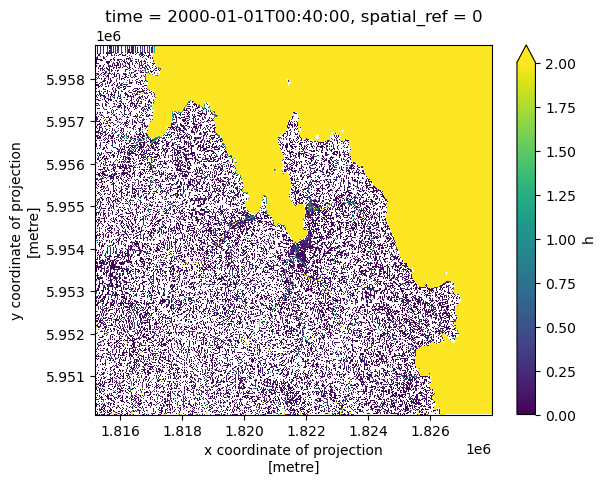

In [29]:
dsout.h[4].plot(vmin=0, vmax=2)

In [33]:
dsout


<xarray.Dataset> Size: 634MB
Dimensions:      (time: 13, x: 1600, y: 1088)
Coordinates:
  * time         (time) datetime64[ns] 104B 2000-01-01 ... 2000-01-01T02:00:00
  * x            (x) float64 13kB 1.815e+06 1.815e+06 ... 1.828e+06 1.828e+06
  * y            (y) float64 9kB 5.95e+06 5.95e+06 ... 5.959e+06 5.959e+06
    spatial_ref  int64 8B 0
Data variables:
    h            (time, y, x) float32 91MB nan nan nan nan ... nan nan nan nan
    u            (time, y, x) float32 91MB nan nan nan nan ... nan nan nan nan
    v            (time, y, x) float32 91MB nan nan nan nan ... nan nan nan nan
    zs           (time, y, x) float32 91MB 178.1 178.1 176.5 ... nan nan nan
    hmax         (time, y, x) float32 91MB nan nan nan nan ... nan nan nan nan
    zsmax        (time, y, x) float32 91MB nan nan nan nan ... nan nan nan nan
    Umax         (time, y, x) float32 91MB nan nan nan nan ... nan nan nan nan